<h1>EDA Pipeline — aplicado a un dataset de Delinquency Prediction <a id="inicio"> </h1>
<em>Notebook desarrollado por Evelyn Cabrera Arias.</em><br><br>

<b>Archivo:</b> <code>data_set_delinquency_prediction.xlsx</code><br>
<b>Registros:</b> 500 clientes &nbsp;·&nbsp; <b>Variables:</b> 19<br>
<b>Variable objetivo:</b> <code>Delinquent_Account</code> (0 = al día · 1 = moroso)

<hr>

<h3 style="color: #0d47a1;">Estructura del pipeline</h3>

<a href="#seccion-1"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">1. Carga de datos</a>
<a href="#seccion-2"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">2. Revisión estructural</a>
<a href="#seccion-3"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">3. Análisis de valores nulos</a>
<a href="#seccion-4"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">4. Estadística descriptiva</a>
<a href="#seccion-5"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">5. Distribuciones — variables numéricas</a>
<a href="#seccion-6"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">6. Boxplots — detección visual de diferencias por grupo</a> 
<a href="#seccion-7"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">7. Variables categóricas</a>
<a href="#seccion-8"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">8. Historial de pagos — Month_1 a Month_6</a>
<a href="#seccion-9"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">9. Correlación con la variable objetivo</a>
<a href="#seccion-10" style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">10. Detección de outliers — Z-score</a>
<a href="#seccion-11" style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">11. Limpieza y tratamiento de datos</a>
<a href="#seccion-12" style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">12. Exportación del dataset limpio</a>
<a href="#seccion-13" style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">13. Resumen de hallazgos</a>

## 1. Carga de datos <a id="seccion-1"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)

df = pd.read_excel('../data/raw/data_set_delinquency_prediction.xlsx')
print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

✅ Dataset cargado: 500 filas × 19 columnas


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.00,398.00,0.39,3,0,16310.00,0.32,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.00,493.00,0.31,6,1,17401.00,0.20,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.00,500.00,0.36,0,0,13761.00,0.30,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.00,413.00,0.37,3,0,88778.00,0.26,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.00,487.00,0.23,2,0,13316.00,0.51,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


## 2. Revisión estructural<a id="seccion-2"></a>

In [2]:
print("====== Tipos de datos ======")
print(df.dtypes)
print(f"\n=== Duplicados: {df.duplicated().sum()} ===")
print(f"=== IDs únicos: {df['Customer_ID'].nunique()} ===")

====== Tipos de datos ======
Customer_ID                 str
Age                       int64
Income                  float64
Credit_Score            float64
Credit_Utilization      float64
Missed_Payments           int64
Delinquent_Account        int64
Loan_Balance            float64
Debt_to_Income_Ratio    float64
Employment_Status           str
Account_Tenure            int64
Credit_Card_Type            str
Location                    str
Month_1                     str
Month_2                     str
Month_3                     str
Month_4                     str
Month_5                     str
Month_6                     str
dtype: object

=== Duplicados: 0 ===
=== IDs únicos: 500 ===


In [3]:
# Clasificar variables por tipo
num_cols = ['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
            'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']
cat_cols = ['Employment_Status', 'Credit_Card_Type', 'Location']
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6']
target = 'Delinquent_Account'

print(f"Variables numéricas ({len(num_cols)}): {num_cols}")
print(f"Variables categóricas ({len(cat_cols)}): {cat_cols}")
print(f"Historial de pagos ({len(month_cols)}): {month_cols}")
print(f"Variable objetivo: {target}")
print(f"\nDistribución objetivo:")
print(df[target].value_counts().rename({0:'No moroso', 1:'Moroso'}))
print(f"Tasa de morosidad: {df[target].mean()*100:.1f}%")

Variables numéricas (8): ['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']
Variables categóricas (3): ['Employment_Status', 'Credit_Card_Type', 'Location']
Historial de pagos (6): ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']
Variable objetivo: Delinquent_Account

Distribución objetivo:
Delinquent_Account
No moroso    420
Moroso        80
Name: count, dtype: int64
Tasa de morosidad: 16.0%


## 3. Análisis de valores nulos<a id="seccion-3"></a>

In [4]:
nulls = df.isnull().sum()
pct   = (nulls / len(df) * 100).round(2)
missing = pd.DataFrame({'nulos': nulls, 'porcentaje_%': pct})
missing_found = missing[missing['nulos'] > 0]
print("Variables con valores nulos:")
print(missing_found.to_string())

Variables con valores nulos:
              nulos  porcentaje_%
Income           39          7.80
Credit_Score      2          0.40
Loan_Balance     29          5.80


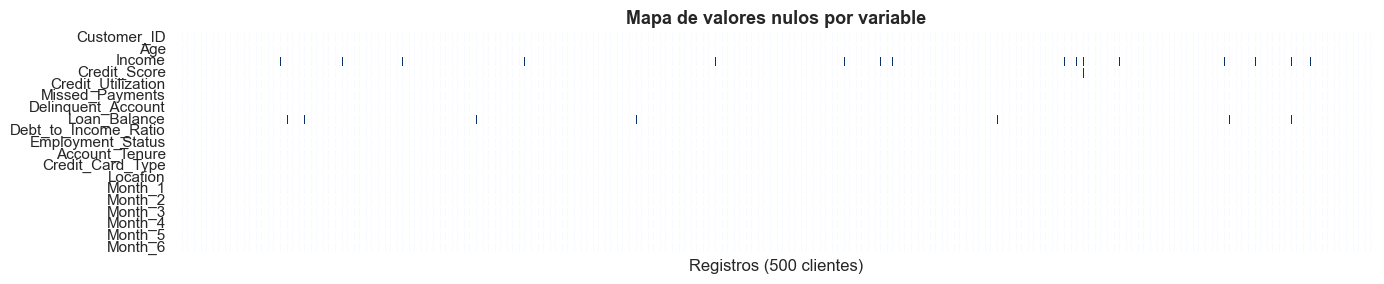


Total de valores nulos: 70
  · Income:       39 nulos (7.8%)
  · Loan_Balance: 29 nulos (5.8%)
  · Credit_Score: 2 nulos (0.4%)


In [5]:
# Heatmap de nulos
plt.figure(figsize=(14, 3))
sns.heatmap(df.isnull().T, cbar=False, cmap='Blues',
            xticklabels=False, yticklabels=True, linewidths=0.3)
plt.title('Mapa de valores nulos por variable', fontweight='bold', fontsize=13)
plt.xlabel('Registros (500 clientes)')
plt.tight_layout()
plt.savefig('../outputs/plots/01_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")
print(f"  · Income:       {df['Income'].isnull().sum()} nulos ({df['Income'].isnull().mean()*100:.1f}%)")
print(f"  · Loan_Balance: {df['Loan_Balance'].isnull().sum()} nulos ({df['Loan_Balance'].isnull().mean()*100:.1f}%)")
print(f"  · Credit_Score: {df['Credit_Score'].isnull().sum()} nulos ({df['Credit_Score'].isnull().mean()*100:.1f}%)")

## 4. Estadística descriptiva<a id="seccion-4"></a>

In [6]:
df[num_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

,count,mean,std,min,25%,50%,75%,max
Age,500.000000,46.266000,16.187629,18.000000,33.000000,46.500000,59.250000,74.000000
Income,461.000000,108379.893709,53662.723741,15404.000000,62295.000000,107658.000000,155734.000000,199943.000000
Credit_Score,498.000000,577.716867,168.881211,301.000000,418.250000,586.000000,727.250000,847.000000
Credit_Utilization,500.000000,0.491446,0.197103,0.050000,0.356486,0.485636,0.634440,1.025843
Missed_Payments,500.000000,2.968000,1.946935,0.000000,1.000000,3.000000,5.000000,6.000000
Loan_Balance,471.000000,48654.428875,29395.537273,612.000000,23716.500000,45776.000000,75546.500000,99620.000000
Debt_to_Income_Ratio,500.000000,0.298862,0.094521,0.100000,0.233639,0.301634,0.362737,0.552956
Account_Tenure,500.000000,9.740000,5.923054,0.000000,5.000000,10.000000,15.000000,19.000000


In [7]:
# Comparar estadísticas entre morosos y no morosos
print("====== Media por grupo (moroso vs no moroso) ======")
comparison = df.groupby(target)[num_cols].mean().T
comparison.columns = ['No moroso (0)', 'Moroso (1)']
comparison['diferencia_%'] = ((comparison['Moroso (1)'] - comparison['No moroso (0)'])
                               / comparison['No moroso (0)'] * 100).round(1)
print(comparison.to_string())

====== Media por grupo (moroso vs no moroso) ======
                      No moroso (0)  Moroso (1)  diferencia_%
Age                           46.11       47.10          2.20
Income                    107306.94   113902.01          6.10
Credit_Score                 575.15      591.15          2.80
Credit_Utilization             0.49        0.51          3.80
Missed_Payments                2.99        2.85         -4.70
Loan_Balance               48708.76    48358.23         -0.70
Debt_to_Income_Ratio           0.30        0.31          3.00
Account_Tenure                 9.84        9.20         -6.50


## 5. Distribuciones — variables numéricas<a id="seccion-5"></a>

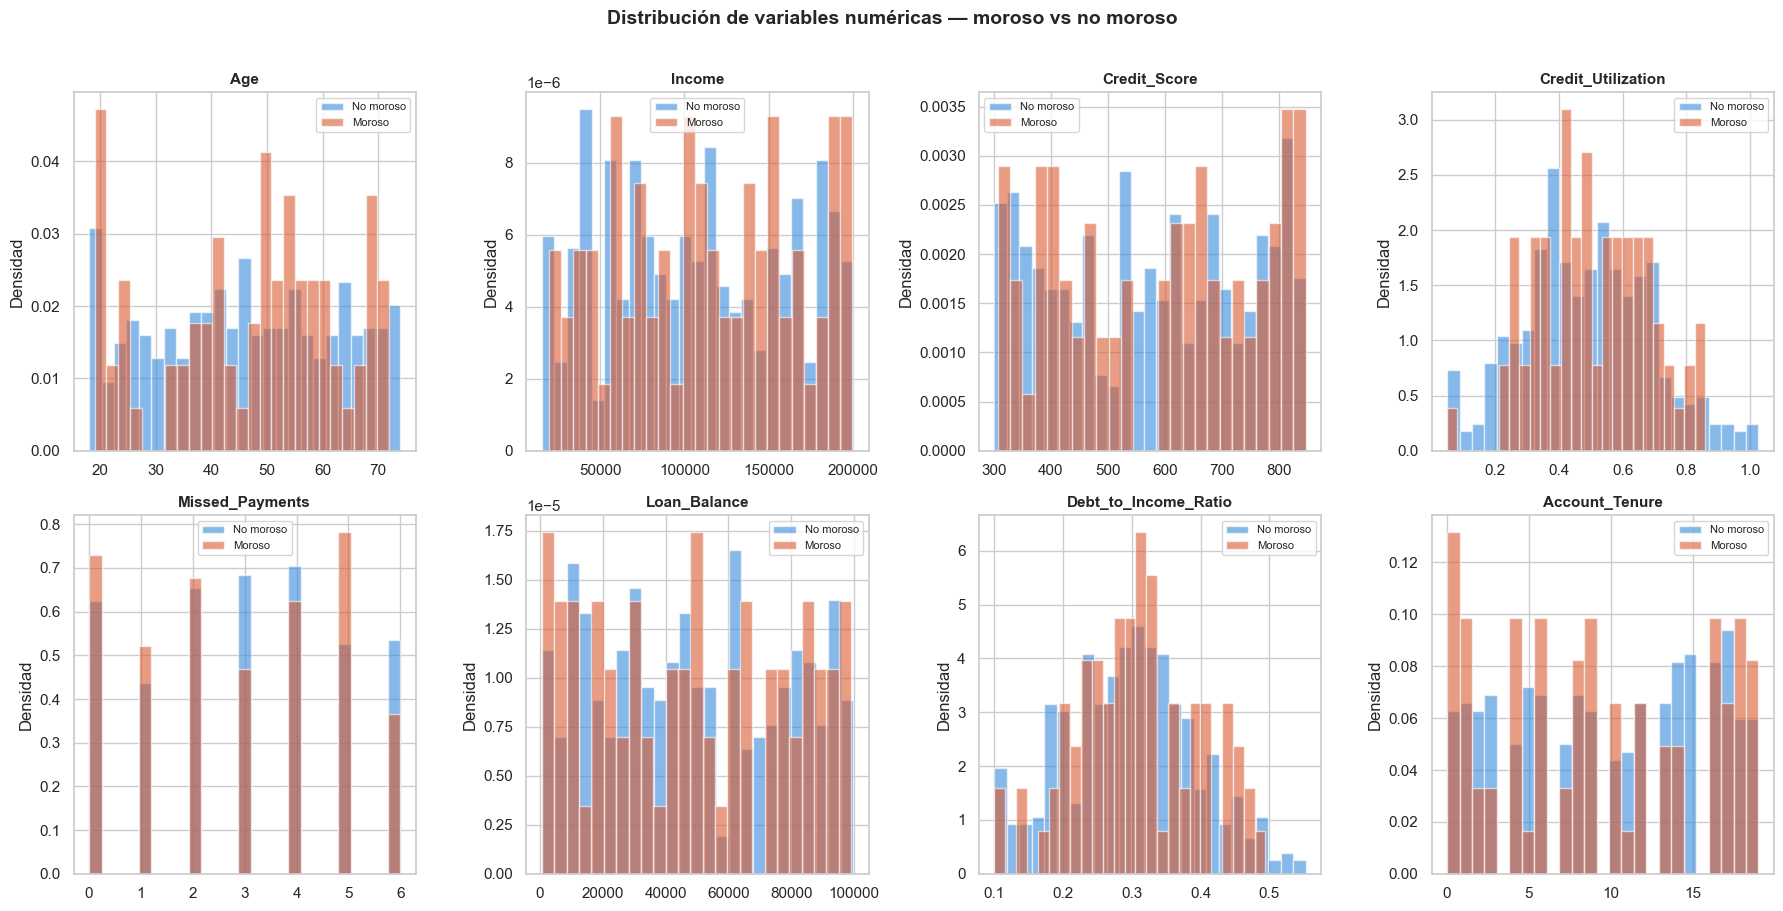

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
colors = ['#378ADD','#D85A30']

for i, col in enumerate(num_cols):
    for val, color, label in zip([0, 1], colors, ['No moroso', 'Moroso']):
        subset = df[df[target] == val][col].dropna()
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas — moroso vs no moroso',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/plots/02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Boxplots — detección visual de diferencias por grupo<a id="seccion-6"></a>

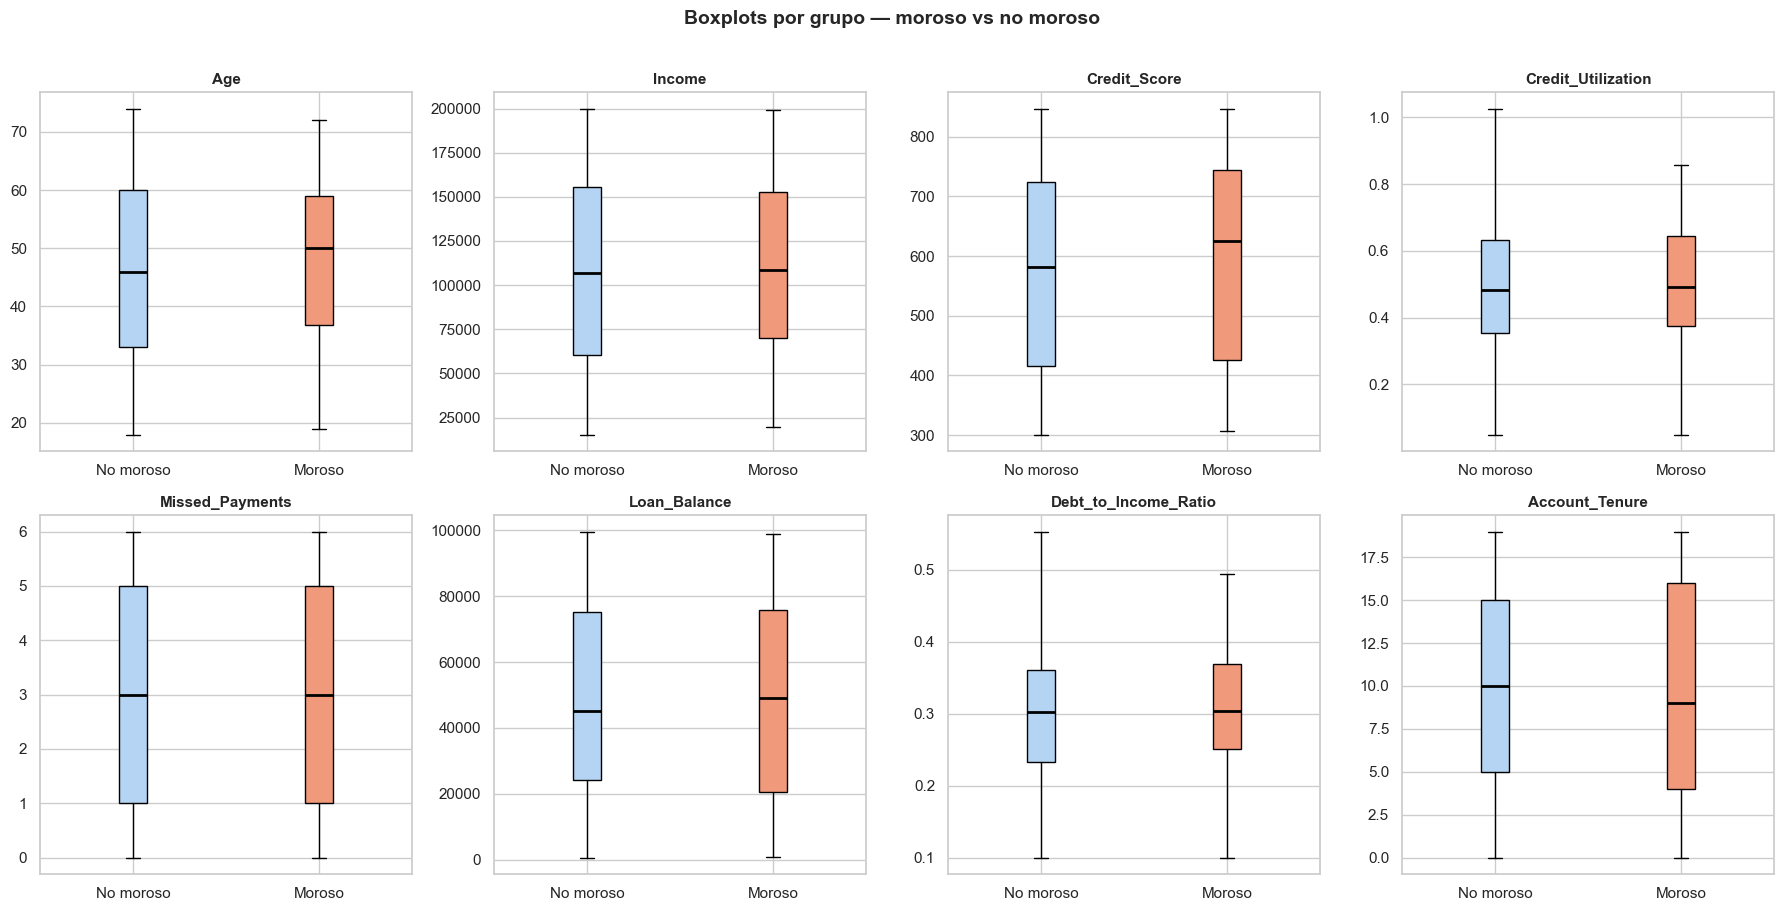

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data_0 = df[df[target]==0][col].dropna()
    data_1 = df[df[target]==1][col].dropna()
    bp = axes[i].boxplot([data_0, data_1],
                          patch_artist=True,
                          labels=['No moroso', 'Moroso'],
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#B5D4F4')
    bp['boxes'][1].set_facecolor('#F0997B')
    axes[i].set_title(col, fontweight='bold', fontsize=11)

plt.suptitle('Boxplots por grupo — moroso vs no moroso',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/plots/03_boxplots_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Variables categóricas<a id="seccion-7"></a>

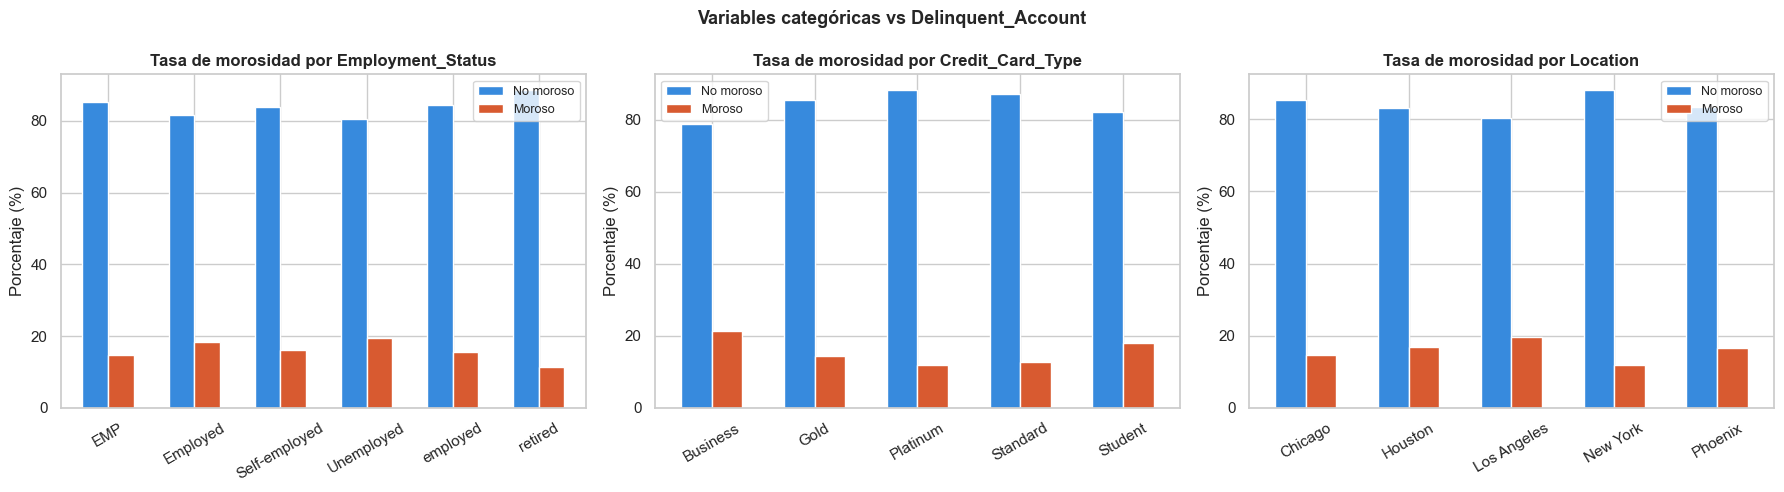

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ['#378ADD', '#D85A30']

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    ct.columns = ['No moroso', 'Moroso']
    ct.plot(kind='bar', ax=ax, color=palette, edgecolor='white', width=0.6)
    ax.set_title(f'Tasa de morosidad por {col}', fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)

plt.suptitle('Variables categóricas vs Delinquent_Account', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/04_categorical_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Inconsistencias en Employment_Status
print("====== Valores únicos Employment_Status ======")
print(df['Employment_Status'].value_counts().to_string())
print("\n⚠️  Inconsistencia detectada: 'EMP', 'employed', 'Employed' representan la misma categoría")
print("    → Se estandarizará en el paso de limpieza")

====== Valores únicos Employment_Status ======
Employment_Status
Unemployed       93
retired          87
Employed         82
EMP              81
Self-employed    80
employed         77

⚠️  Inconsistencia detectada: 'EMP', 'employed', 'Employed' representan la misma categoría
    → Se estandarizará en el paso de limpieza


## 8. Historial de pagos — Month_1 a Month_6<a id="seccion-8"></a>

In [12]:
# Distribución de categorías de pago por mes
month_summary = pd.DataFrame()
for col in month_cols:
    vc = df[col].value_counts(normalize=True).mul(100).round(1)
    month_summary[col] = vc

month_summary = month_summary.T
print("Distribución (%) de estados de pago por mes:")
print(month_summary.to_string())

Distribución (%) de estados de pago por mes:
Month_1  On-time  Missed  Late
Month_1    35.40   32.80 31.80
Month_2    32.00   33.40 34.60
Month_3    33.80   32.40 33.80
Month_4    31.80   32.00 36.20
Month_5    32.40   37.40 30.20
Month_6    32.00   33.60 34.40


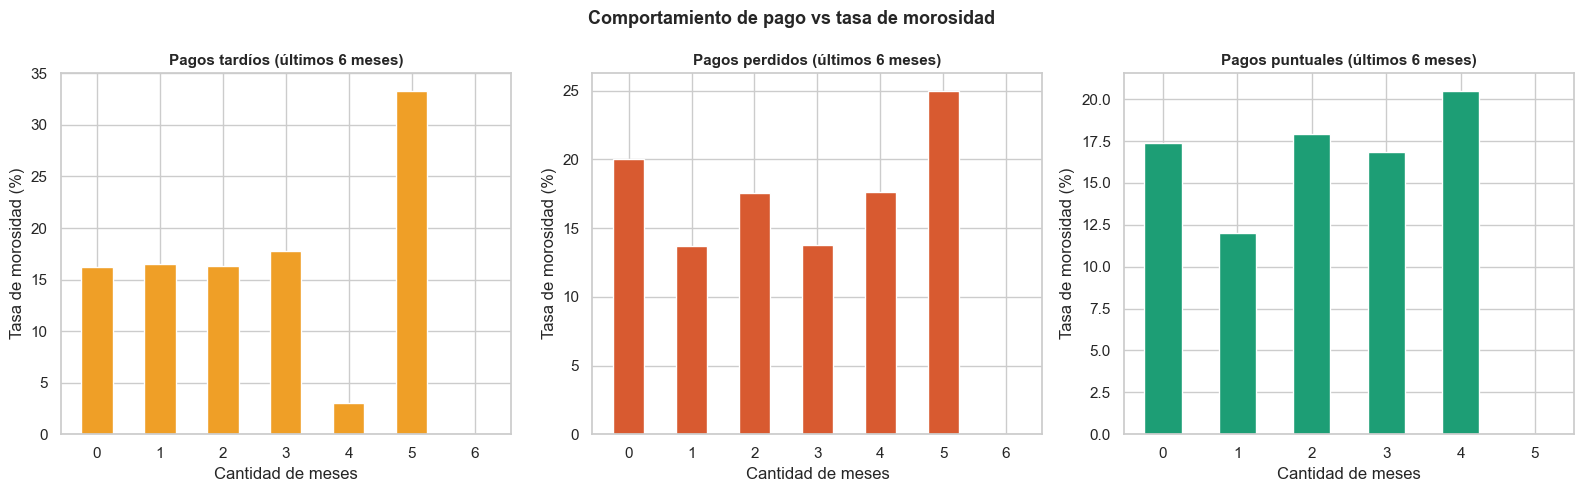

In [13]:
# Tasa de mora según frecuencia de pagos tardíos/perdidos
df['pagos_tardios'] = df[month_cols].apply(lambda row: (row == 'Late').sum(), axis=1)
df['pagos_perdidos'] = df[month_cols].apply(lambda row: (row == 'Missed').sum(), axis=1)
df['pagos_puntuales'] = df[month_cols].apply(lambda row: (row == 'On-time').sum(), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color, label in zip(
    axes,
    ['pagos_tardios', 'pagos_perdidos', 'pagos_puntuales'],
    ['#EF9F27', '#D85A30', '#1D9E75'],
    ['Pagos tardíos (últimos 6 meses)',
     'Pagos perdidos (últimos 6 meses)',
     'Pagos puntuales (últimos 6 meses)']
):
    rate = df.groupby(col)[target].mean().mul(100)
    ax.bar(rate.index, rate.values, color=color, edgecolor='white', width=0.5)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('Cantidad de meses')
    ax.set_ylabel('Tasa de morosidad (%)')

plt.suptitle('Comportamiento de pago vs tasa de morosidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/05_payment_history.png', dpi=150, bbox_inches='tight')
plt.show()

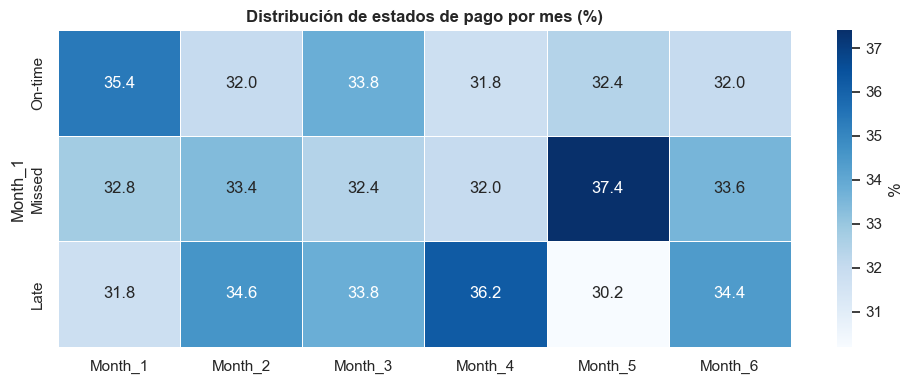

In [14]:
# Heatmap: distribución de pagos por mes
month_pct = pd.DataFrame()
for col in month_cols:
    month_pct[col] = df[col].value_counts(normalize=True).mul(100)

plt.figure(figsize=(10, 4))
sns.heatmap(month_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': '%'})
plt.title('Distribución de estados de pago por mes (%)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/06_payment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Correlación con la variable objetivo<a id="seccion-9"></a>

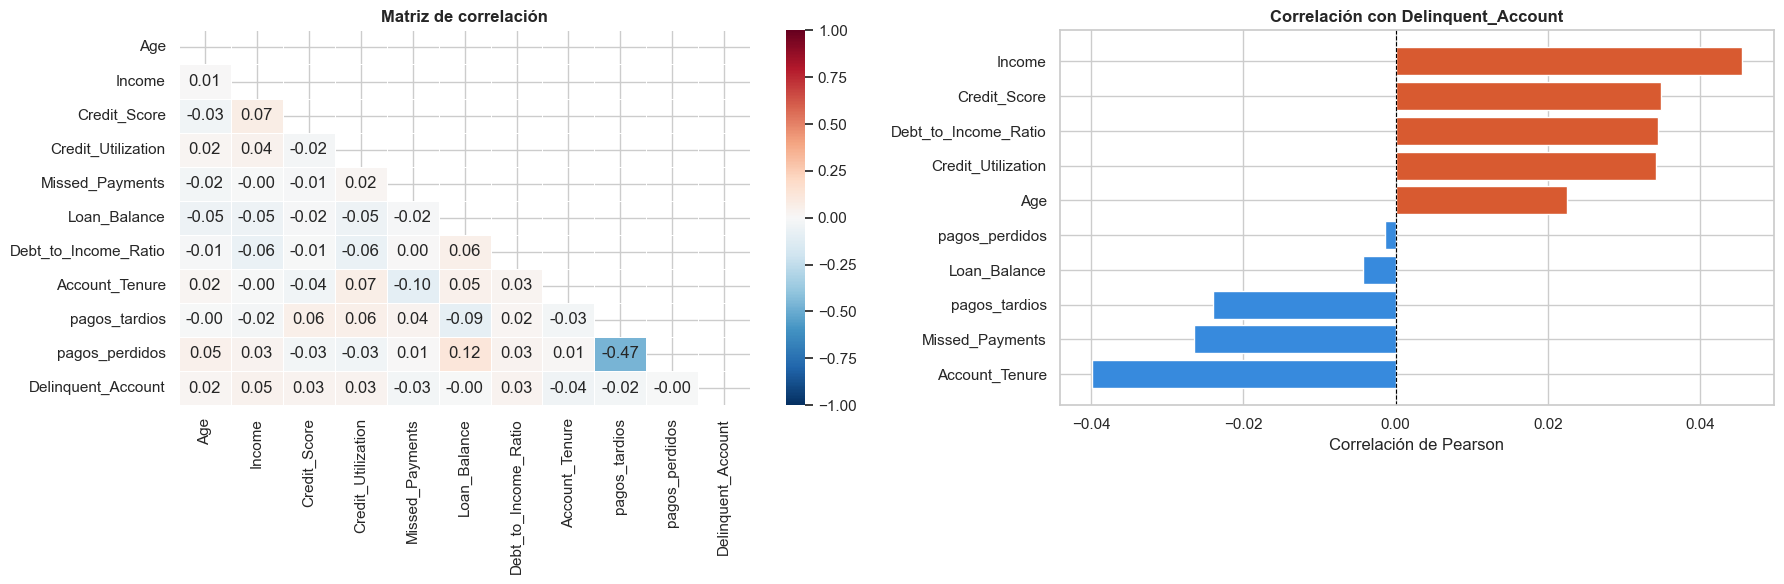

In [15]:
# Matriz de correlación — variables numéricas + features derivadas + target
corr_cols = num_cols + ['pagos_tardios', 'pagos_perdidos', target]
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mapa de calor completo
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=axes[0],
            linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Matriz de correlación', fontweight='bold')

# Correlación con target
corr_target = corr_matrix[target].drop(target).sort_values()
colors_bar = ['#D85A30' if v > 0 else '#378ADD' for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Correlación con Delinquent_Account', fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.savefig('../outputs/plots/07_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Detección de outliers — Z-score<a id="seccion-10"></a>

In [16]:
from scipy import stats

print("====== Detección de outliers (|z-score| > 3) ======")
outlier_summary = {}
for col in num_cols:
    col_data = df[col].dropna()
    z_scores = np.abs(stats.zscore(col_data))
    n_outliers = (z_scores > 3).sum()
    outlier_summary[col] = {
        'outliers': n_outliers,
        'pct_%': round(n_outliers / len(col_data) * 100, 2),
        'min': col_data.min(),
        'max': col_data.max()
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df.to_string())

====== Detección de outliers (|z-score| > 3) ======
                      outliers  pct_%      min       max
Age                       0.00   0.00    18.00     74.00
Income                    0.00   0.00 15404.00 199943.00
Credit_Score              0.00   0.00   301.00    847.00
Credit_Utilization        0.00   0.00     0.05      1.03
Missed_Payments           0.00   0.00     0.00      6.00
Loan_Balance              0.00   0.00   612.00  99620.00
Debt_to_Income_Ratio      0.00   0.00     0.10      0.55
Account_Tenure            0.00   0.00     0.00     19.00


## 11. Limpieza y tratamiento de datos<a id="seccion-11"></a>

In [17]:
df_clean = df.copy()

# 11.1 Estandarizar Employment_Status
emp_map = {
    'EMP': 'Employed',
    'employed': 'Employed',
    'Employed': 'Employed',
    'Unemployed': 'Unemployed',
    'Self-employed': 'Self-Employed',
    'retired': 'Retired'
}
df_clean['Employment_Status'] = df_clean['Employment_Status'].map(emp_map)
print("✅ Employment_Status estandarizado:")
print(df_clean['Employment_Status'].value_counts().to_string())

✅ Employment_Status estandarizado:
Employment_Status
Employed         240
Unemployed        93
Retired           87
Self-Employed     80


In [18]:
# 11.2 Imputación de valores nulos
# Income: mediana (distribución sesgada)
df_clean['Income_missing'] = df_clean['Income'].isnull().astype(int)
df_clean['Income'] = df_clean['Income'].fillna(df_clean['Income'].median())

# Loan_Balance: mediana por Employment_Status (segmentada)
df_clean['Loan_Balance_missing'] = df_clean['Loan_Balance'].isnull().astype(int)
df_clean['Loan_Balance'] = df_clean.groupby('Employment_Status')['Loan_Balance']    .transform(lambda x: x.fillna(x.median()))

# Credit_Score: mediana (tasa de nulos baja < 1%)
df_clean['Credit_Score_missing'] = df_clean['Credit_Score'].isnull().astype(int)
df_clean['Credit_Score'] = df_clean['Credit_Score'].fillna(df_clean['Credit_Score'].median())

print("✅ Imputación completada")
print(f"   Nulos restantes: {df_clean.isnull().sum().sum()}")

✅ Imputación completada
   Nulos restantes: 0


In [19]:
# 11.3 Convertir historial de pagos a numérico ordinal
# 0 = On-time  |  1 = Late  |  2 = Missed
payment_map = {'On-time': 0, 'Late': 1, 'Missed': 2}
for col in month_cols:
    df_clean[col + '_num'] = df_clean[col].map(payment_map)

print("✅ Historial de pagos convertido a numérico:")
print(df_clean[[col + '_num' for col in month_cols]].head(3).to_string())

✅ Historial de pagos convertido a numérico:
   Month_1_num  Month_2_num  Month_3_num  Month_4_num  Month_5_num  Month_6_num
0            1            1            2            1            2            1
1            2            2            1            2            0            0
2            2            1            1            0            2            1


In [20]:
# 11.4 Feature engineering — señales de comportamiento de pago
month_num_cols = [col + '_num' for col in month_cols]
df_clean['total_late_payments']   = df_clean[month_num_cols].apply(lambda r: (r == 1).sum(), axis=1)
df_clean['total_missed_payments'] = df_clean[month_num_cols].apply(lambda r: (r == 2).sum(), axis=1)
df_clean['payment_score']         = df_clean[month_num_cols].sum(axis=1)  # mayor = peor comportamiento
df_clean['worst_recent_payment']  = df_clean[month_num_cols].max(axis=1)

print("✅ Features de comportamiento de pago creadas:")
df_clean[['Customer_ID','payment_score','total_late_payments',
          'total_missed_payments','worst_recent_payment']].head(8)

✅ Features de comportamiento de pago creadas:


,Customer_ID,payment_score,total_late_payments,total_missed_payments,worst_recent_payment
0,CUST0001,8,4,2,2
1,CUST0002,7,1,3,2
2,CUST0003,7,3,2,2
3,CUST0004,8,4,2,2
4,CUST0005,7,3,2,2
5,CUST0006,8,2,3,2
6,CUST0007,8,2,3,2
7,CUST0008,4,2,1,2


In [21]:
# Verificar distribución de variables limpias
print("====== Dataset limpio ======")
print(f"Shape: {df_clean.shape}")
print(f"Nulos: {df_clean.isnull().sum().sum()}")
print(f"Employment_Status únicos: {df_clean['Employment_Status'].unique()}")

====== Dataset limpio ======
Shape: (500, 35)
Nulos: 0
Employment_Status únicos: <StringArray>
['Employed', 'Self-Employed', 'Unemployed', 'Retired']
Length: 4, dtype: str


## 12. Exportación del dataset limpio<a id="seccion-12"></a>

In [22]:
# Guardar dataset limpio completo
df_clean.to_csv('../data/clean/delinquency_clean.csv', index=False)
print("✅ Dataset limpio exportado → /data/clean/delinquency_clean.csv")
print(f"   Shape final: {df_clean.shape}")

# Guardar resumen de nulos antes/después
summary = pd.DataFrame({
    'nulos_original': df.isnull().sum(),
    'nulos_limpio':   df_clean[df.columns].isnull().sum()
})
summary['tratamiento'] = summary.apply(lambda r:
    'Imputación mediana' if r['nulos_original'] > 0 else 'Sin nulos', axis=1)
summary[summary['nulos_original'] > 0].to_csv('../outputs/reports/missing_treatment.csv')
print("✅ Resumen de tratamiento exportado → /outputs/reports/missing_treatment.csv")

✅ Dataset limpio exportado → /data/clean/delinquency_clean.csv
   Shape final: (500, 35)
✅ Resumen de tratamiento exportado → /outputs/reports/missing_treatment.csv


## 13. Resumen de hallazgos<a id="seccion-13"></a>

In [23]:
print("=" * 55)
print("  RESUMEN EDA — DELINQUENCY PREDICTION DATASET")
print("=" * 55)
print(f"  Registros:          {len(df):,}")
print(f"  Variables originales: {df.shape[1]}")
print(f"  Variables finales:    {df_clean.shape[1]}")
print(f"  Tasa de morosidad:   {df[target].mean()*100:.1f}%")
print()
print("  CALIDAD DE DATOS:")
print(f"  · Duplicados:        0")
print(f"  · Income nulos:      {df['Income'].isnull().sum()} ({df['Income'].isnull().mean()*100:.1f}%) → imputado")
print(f"  · Loan_Balance nulos:{df['Loan_Balance'].isnull().sum()} ({df['Loan_Balance'].isnull().mean()*100:.1f}%) → imputado")
print(f"  · Credit_Score nulos:{df['Credit_Score'].isnull().sum()} ({df['Credit_Score'].isnull().mean()*100:.1f}%) → imputado")
print(f"  · Employment_Status: inconsistencias estandarizadas")
print(f"  · Month_1–Month_6:   texto → numérico ordinal")
print()
print("  INDICADORES DE RIESGO IDENTIFICADOS:")
print("  · Pagos perdidos/tardíos = señal fuerte de morosidad")
print("  · Credit_Utilization alta → mayor riesgo")
print("  · Credit_Score bajo → mayor riesgo")
print("  · Debt_to_Income_Ratio alto → mayor riesgo")
print("  · Correlaciones lineales débiles → usar modelos no lineales")
print()
print("  PRÓXIMO PASO: Utilizarlo en modelamiento predictivo")
print("=" * 55)

  RESUMEN EDA — DELINQUENCY PREDICTION DATASET
  Registros:          500
  Variables originales: 22
  Variables finales:    35
  Tasa de morosidad:   16.0%

  CALIDAD DE DATOS:
  · Duplicados:        0
  · Income nulos:      39 (7.8%) → imputado
  · Loan_Balance nulos:29 (5.8%) → imputado
  · Credit_Score nulos:2 (0.4%) → imputado
  · Employment_Status: inconsistencias estandarizadas
  · Month_1–Month_6:   texto → numérico ordinal

  INDICADORES DE RIESGO IDENTIFICADOS:
  · Pagos perdidos/tardíos = señal fuerte de morosidad
  · Credit_Utilization alta → mayor riesgo
  · Credit_Score bajo → mayor riesgo
  · Debt_to_Income_Ratio alto → mayor riesgo
  · Correlaciones lineales débiles → usar modelos no lineales

  PRÓXIMO PASO: Utilizarlo en modelamiento predictivo


<h3 style="color: #0d47a1;">Próximos pasos</h3>

- Encoding de variables categóricas para modelamiento
- Feature selection basada en importancia de variables
- Explorar modelos no lineales (árbol de decisión, Random Forest) para capturar relaciones complejas
- Validación cruzada para evitar overfitting en dataset pequeño (500 registros)

<em><a href="#inicio"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">Volver a inicio del eda-pipeline</a></em>

<em><a href=https://github.com/evelyncabrera-pe/portfolio-evelyn-cabrera style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">Ir a Portafolio</a></em>